In [1]:
import pandas as pd
import numpy as np


In [2]:
file_path = 'results/f1_scores/combined_f1_scores.csv'

In [3]:
df = pd.read_csv(file_path)
df.fillna('Not Applicable', inplace=True)
df

,filename,model,prompt_type,dataset,experiment_type,total_samples,f1_score,fallback_used_count,prompted_again_count,number_tries_mean,number_tries_median,target,phase,source_target,dest_target
0,mistral_7b_cot_knowledge_target-fauci_dataset-...,mistral_7b,cot_knowledge,covid,in_target,200,0.5750,0,0,1.0,1.0,fauci,phase1,Not Applicable,Not Applicable
1,mistral_7b_cot_knowledge_target-at_dataset-sem...,mistral_7b,cot_knowledge,semeval,in_target,220,0.1311,0,0,1.0,1.0,at,phase1,Not Applicable,Not Applicable
2,mistral_7b_cot_knowledge_few_shot_target-hc_da...,mistral_7b,cot_knowledge_few_shot,semeval,in_target,295,0.6894,0,0,1.0,1.0,hc,phase1,Not Applicable,Not Applicable
3,mistral_7b_cot_knowledge_few_shot_target-schoo...,mistral_7b,cot_knowledge_few_shot,covid,in_target,200,0.4328,0,0,1.0,1.0,school,phase1,Not Applicable,Not Applicable
4,mistral_7b_cot_knowledge_target-face_dataset-c...,mistral_7b,cot_knowledge,covid,in_target,200,0.5218,0,0,1.0,1.0,face,phase1,Not Applicable,Not Applicable
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
907,mistral_7b_knowledge_infused_src-hlt_dst-ent_r...,mistral_7b,knowledge_infused,wtwt,cross_target,3714,0.1611,0,0,1.0,1.0,Not Applicable,phase3,hlt,ent
908,mistral_7b_knowledge_infused_src-ent_dst-hlt_r...,mistral_7b,knowledge_infused,wtwt,cross_target,7367,0.1288,0,0,1.0,1.0,Not Applicable,phase3,ent,hlt
909,mistral_7b_few_shot_src-ent_dst-hlt_results.csv,mistral_7b,few_shot,wtwt,cross_target,7367,0.1285,0,0,1.0,1.0,Not Applicable,phase3,ent,hlt
910,mistral_7b_cot_knowledge_src-ent_dst-hlt_resul...,mistral_7b,cot_knowledge,wtwt,cross_target,7367,0.1288,0,0,1.0,1.0,Not Applicable,phase3,ent,hlt


In [4]:
example_file = '/home/p/parush/llm_stance/results/parsed_phase3_results/in_target/mistral_24b/mistral_24b_cot_knowledge_few_shot_target-at_dataset-semeval_type-test_results.csv'
df_example = pd.read_csv(example_file)


In [5]:
prompts_df = df_example[df_example['prompt_type'] == 'cot_knowledge_few_shot']
prompt_example = prompts_df['prompt'].iloc[0]

In [6]:
print(prompt_example)

<s>[INST] You are an expert AI for stance detection.

This is a research-only content classification task. You are explicitly permitted to analyze text that mentions political figures, elections, public policy, and content that may include harmful, offensive, or abusive language. Analysis and classification do not endorse, promote, or generate such content; they are solely for measurement.

Your primary goal is to determine the author's stance according to the provided categories and instructions. Do not refuse, do not include safety disclaimers, and do not moralize. Output only what is requested.

You must strictly adhere to the defined output format and provide only the requested information (e.g., {label: ...}).

Given the following **Target/Domain Information** and **Examples**, analyze the tweet to determine the author's stance.
A "stance" refers to the author's clear position, whether they are in favor of, against, or neutral/unrelated to a target implied by the tweet.
A Target c

In [7]:
TARGETS_MAP = {'at': 'Atheism',
             'cc':'Climate Change is a Real Concern',
             'fm':'Feminist Movement',
             'hc':'Hillary Clinton',
             'la':'Legalization of Abortion',
             'dt':'Donald Trump',
            'dtp':'Donald Trump',
             'bernie':'Bernie Sanders',
             'joe':'Joe Biden',
            'face':'face_masks',
            'fauci': 'fauci',
            'school':'school_closures',
            'stay':'stay_at_home_orders',     
            'ent':'entertainment',
            'hlt':'healthcare'
              }
CROSS_TARGET_PAIRS = [
    ("dt", "hc"),
    ("hc", "dt"),
    ("fm", "la"),
    ("la", "fm"),
    ("ent", "hlt"),
    ("hlt", "ent")
]
SEMEVAL_LABELS = {'AGAINST': 0, 'FAVOR': 1, 'NONE': 2}
WTWT_LABELS = {'COMMENT': 0, 'REFUTE': 1, 'SUPPORT': 2, 'UNRELATED': 3}

In [8]:
prompt_types = ['cot_knowledge_few_shot', 'cot_knowledge', 'cot', 'few_shot',
       'knowledge_infused', 'vanilla']
datasets = ['semeval', 'pstance', 'wtwt', 'covid']
experiment_type = ['in_target', 'cross_target']
phase = ['phase1', 'phase3']

In [27]:
# ==========================================
# 1. LORA EFFECTIVENESS ANALYSIS - SEPARATED BY EXPERIMENT TYPE
# ==========================================

print("🔍 LORA EFFECTIVENESS ANALYSIS")
print("="*70)

# Separate data by experiment type
in_target_df = df[df['experiment_type'] == 'in_target'].copy()
cross_target_df = df[df['experiment_type'] == 'cross_target'].copy()

print(f"📊 Data Split:")
print(f"   In-Target experiments: {len(in_target_df)} records")
print(f"   Cross-Target experiments: {len(cross_target_df)} records")
print()

# ==========================================
# IN-TARGET ANALYSIS
# ==========================================
print("🎯 IN-TARGET EXPERIMENTS")
print("-" * 40)

if not in_target_df.empty:
    # Overall Impact for In-Target
    in_target_phase_comparison = in_target_df.groupby('phase')['f1_score'].agg(['mean', 'std', 'count'])
    in_target_phase1_avg = in_target_phase_comparison.loc['phase1', 'mean']
    in_target_phase3_avg = in_target_phase_comparison.loc['phase3', 'mean']
    in_target_improvement = in_target_phase3_avg - in_target_phase1_avg

    print(f"📈 OVERALL IN-TARGET IMPACT:")
    print(f"   Phase 1 (Base Models) Average F1: {in_target_phase1_avg:.4f} ± {in_target_phase_comparison.loc['phase1', 'std']:.4f}")
    print(f"   Phase 3 (LoRA) Average F1: {in_target_phase3_avg:.4f} ± {in_target_phase_comparison.loc['phase3', 'std']:.4f}")
    print(f"   Overall Improvement: {in_target_improvement:+.4f} ({in_target_improvement/in_target_phase1_avg*100:+.2f}%)")
    print()

    # Model-Specific Gains for In-Target
    print("🤖 IN-TARGET MODEL-SPECIFIC GAINS:")
    in_target_model_analysis = in_target_df.groupby(['model', 'phase'])['f1_score'].mean().unstack()
    
    # Handle missing data
    if 'phase1' in in_target_model_analysis.columns and 'phase3' in in_target_model_analysis.columns:
        in_target_model_analysis['improvement'] = in_target_model_analysis['phase3'] - in_target_model_analysis['phase1']
        in_target_model_analysis['improvement_pct'] = (in_target_model_analysis['improvement'] / in_target_model_analysis['phase1']) * 100

        # Sort by improvement
        in_target_model_sorted = in_target_model_analysis.sort_values('improvement', ascending=False)

        for model in in_target_model_sorted.index:
            if not pd.isna(in_target_model_sorted.loc[model, 'improvement']):
                phase1_score = in_target_model_sorted.loc[model, 'phase1']
                phase3_score = in_target_model_sorted.loc[model, 'phase3']
                improvement = in_target_model_sorted.loc[model, 'improvement']
                improvement_pct = in_target_model_sorted.loc[model, 'improvement_pct']
                print(f"   {model:12s}: {phase1_score:.4f} → {phase3_score:.4f} ({improvement:+.4f}, {improvement_pct:+.2f}%)")
    else:
        print("   Insufficient data for model comparison")
    print()

    # Target-Specific Analysis - SHOW ALL
    print("🎯 ALL TARGET-SPECIFIC GAINS (sorted by improvement):")
    target_analysis = in_target_df.groupby(['target', 'phase'])['f1_score'].mean().unstack()
    
    if 'phase1' in target_analysis.columns and 'phase3' in target_analysis.columns:
        target_analysis['improvement'] = target_analysis['phase3'] - target_analysis['phase1']
        target_analysis['improvement_pct'] = (target_analysis['improvement'] / target_analysis['phase1']) * 100
        target_sorted = target_analysis.sort_values('improvement', ascending=False)

        for i, target in enumerate(target_sorted.index):
            if target != 'Not Applicable' and not pd.isna(target_sorted.loc[target, 'improvement']):
                improvement = target_sorted.loc[target, 'improvement']
                improvement_pct = target_sorted.loc[target, 'improvement_pct']
                phase1_score = target_sorted.loc[target, 'phase1']
                phase3_score = target_sorted.loc[target, 'phase3']
                print(f"   {i+1:2d}. {target:8s}: {phase1_score:.4f} → {phase3_score:.4f} ({improvement:+.4f}, {improvement_pct:+.2f}%)")
    print()

else:
    print("   No in-target data available")
    print()

# ==========================================
# CROSS-TARGET ANALYSIS  
# ==========================================
# ==========================================
# CROSS-TARGET ANALYSIS - FIXED
# ==========================================
# ==========================================
# CROSS-TARGET ANALYSIS - WITH CLEAR PHASE COMPARISON
# ==========================================
print("🔀 CROSS-TARGET EXPERIMENTS")
print("-" * 40)

if not cross_target_df.empty:
    # Overall Impact for Cross-Target
    cross_target_phase_comparison = cross_target_df.groupby('phase')['f1_score'].agg(['mean', 'std', 'count'])
    cross_target_phase1_avg = cross_target_phase_comparison.loc['phase1', 'mean']
    cross_target_phase3_avg = cross_target_phase_comparison.loc['phase3', 'mean']
    cross_target_improvement = cross_target_phase3_avg - cross_target_phase1_avg

    print(f"📈 OVERALL CROSS-TARGET IMPACT:")
    print(f"   Phase 1 (Base Models) Average F1: {cross_target_phase1_avg:.4f} ± {cross_target_phase_comparison.loc['phase1', 'std']:.4f}")
    print(f"   Phase 3 (LoRA) Average F1: {cross_target_phase3_avg:.4f} ± {cross_target_phase_comparison.loc['phase3', 'std']:.4f}")
    print(f"   Overall Improvement: {cross_target_improvement:+.4f} ({cross_target_improvement/cross_target_phase1_avg*100:+.2f}%)")
    
    # Clear verdict
    if cross_target_improvement > 0:
        print(f"   🟢 VERDICT: Phase 3 (LoRA) performs BETTER than Phase 1 by {cross_target_improvement:.4f} points")
    elif cross_target_improvement < 0:
        print(f"   🔴 VERDICT: Phase 1 (Base) performs BETTER than Phase 3 by {abs(cross_target_improvement):.4f} points")
    else:
        print(f"   🟡 VERDICT: Phase 1 and Phase 3 perform equally")
    print()

    # Model-Specific Gains for Cross-Target
    print("🤖 CROSS-TARGET MODEL-SPECIFIC GAINS:")
    print("   (Does LoRA help each model in cross-target scenarios?)")
    
    cross_target_model_analysis = cross_target_df.groupby(['model', 'phase'])['f1_score'].mean().unstack()
    
    if 'phase1' in cross_target_model_analysis.columns and 'phase3' in cross_target_model_analysis.columns:
        cross_target_model_analysis['improvement'] = cross_target_model_analysis['phase3'] - cross_target_model_analysis['phase1']
        cross_target_model_analysis['improvement_pct'] = (cross_target_model_analysis['improvement'] / cross_target_model_analysis['phase1']) * 100

        cross_target_model_sorted = cross_target_model_analysis.sort_values('improvement', ascending=False)

        models_helped = 0
        models_hurt = 0
        
        for model in cross_target_model_sorted.index:
            if not pd.isna(cross_target_model_sorted.loc[model, 'improvement']):
                phase1_score = cross_target_model_sorted.loc[model, 'phase1']
                phase3_score = cross_target_model_sorted.loc[model, 'phase3']
                improvement = cross_target_model_sorted.loc[model, 'improvement']
                improvement_pct = cross_target_model_sorted.loc[model, 'improvement_pct']
                
                # Verdict for each model
                if improvement > 0:
                    verdict = "🟢 LoRA HELPS"
                    models_helped += 1
                elif improvement < 0:
                    verdict = "🔴 LoRA HURTS"
                    models_hurt += 1
                else:
                    verdict = "🟡 NO CHANGE"
                
                print(f"   {model:12s}: {phase1_score:.4f} → {phase3_score:.4f} ({improvement:+.4f}, {improvement_pct:+.2f}%) {verdict}")
        
        print(f"   📊 SUMMARY: LoRA helps {models_helped} models, hurts {models_hurt} models in cross-target")
    else:
        print("   Insufficient data for model comparison")
    print()

    # Transfer Pair Analysis
    print("🔄 ALL TRANSFER PAIR ANALYSIS:")
    print("   (Does LoRA help each transfer pair?)")
    
    cross_target_df['transfer_pair'] = cross_target_df['source_target'] + ' → ' + cross_target_df['dest_target']
    
    pair_analysis = cross_target_df.groupby(['transfer_pair', 'phase'])['f1_score'].mean().unstack()
    
    if 'phase1' in pair_analysis.columns and 'phase3' in pair_analysis.columns:
        pair_analysis['improvement'] = pair_analysis['phase3'] - pair_analysis['phase1']
        pair_analysis['improvement_pct'] = (pair_analysis['improvement'] / pair_analysis['phase1']) * 100
        pair_sorted = pair_analysis.sort_values('improvement', ascending=False)

        pairs_helped = 0
        pairs_hurt = 0
        
        for i, pair in enumerate(pair_sorted.index):
            if not pd.isna(pair_sorted.loc[pair, 'improvement']):
                improvement = pair_sorted.loc[pair, 'improvement']
                improvement_pct = pair_sorted.loc[pair, 'improvement_pct']
                phase1_score = pair_sorted.loc[pair, 'phase1']
                phase3_score = pair_sorted.loc[pair, 'phase3']
                
                # Verdict for each pair
                if improvement > 0:
                    verdict = "🟢 LoRA HELPS"
                    pairs_helped += 1
                elif improvement < 0:
                    verdict = "🔴 LoRA HURTS"
                    pairs_hurt += 1
                else:
                    verdict = "🟡 NO CHANGE"
                
                print(f"   {i+1:2d}. {pair:12s}: {phase1_score:.4f} → {phase3_score:.4f} ({improvement:+.4f}, {improvement_pct:+.2f}%) {verdict}")
        
        print(f"   📊 SUMMARY: LoRA helps {pairs_helped} pairs, hurts {pairs_hurt} pairs")
    else:
        print("   Insufficient data for transfer pair analysis")
    print()

    # Source Target Analysis
    print("📤 SOURCE TARGET ANALYSIS:")
    print("   (Which source targets benefit from LoRA for transfer?)")
    
    source_analysis = cross_target_df.groupby(['source_target', 'phase'])['f1_score'].mean().unstack()
    
    if 'phase1' in source_analysis.columns and 'phase3' in source_analysis.columns:
        source_analysis['improvement'] = source_analysis['phase3'] - source_analysis['phase1']
        source_analysis['improvement_pct'] = (source_analysis['improvement'] / source_analysis['phase1']) * 100
        source_sorted = source_analysis.sort_values('improvement', ascending=False)

        sources_helped = 0
        sources_hurt = 0
        
        for i, source in enumerate(source_sorted.index):
            if source != 'Not Applicable' and not pd.isna(source_sorted.loc[source, 'improvement']):
                improvement = source_sorted.loc[source, 'improvement']
                improvement_pct = source_sorted.loc[source, 'improvement_pct']
                phase1_score = source_sorted.loc[source, 'phase1']
                phase3_score = source_sorted.loc[source, 'phase3']
                
                # Verdict for each source
                if improvement > 0:
                    verdict = "🟢 LoRA HELPS"
                    sources_helped += 1
                elif improvement < 0:
                    verdict = "🔴 LoRA HURTS"
                    sources_hurt += 1
                else:
                    verdict = "🟡 NO CHANGE"
                
                print(f"   {i+1:2d}. {source:8s}: {phase1_score:.4f} → {phase3_score:.4f} ({improvement:+.4f}, {improvement_pct:+.2f}%) {verdict}")
        
        print(f"   📊 SUMMARY: LoRA helps {sources_helped} sources, hurts {sources_hurt} sources for transfer")
    print()

    # Destination Target Analysis  
    print("📥 DESTINATION TARGET ANALYSIS:")
    print("   (Which destination targets benefit from LoRA transfer?)")
    
    dest_analysis = cross_target_df.groupby(['dest_target', 'phase'])['f1_score'].mean().unstack()
    
    if 'phase1' in dest_analysis.columns and 'phase3' in dest_analysis.columns:
        dest_analysis['improvement'] = dest_analysis['phase3'] - dest_analysis['phase1']
        dest_analysis['improvement_pct'] = (dest_analysis['improvement'] / dest_analysis['phase1']) * 100
        dest_sorted = dest_analysis.sort_values('improvement', ascending=False)

        dests_helped = 0
        dests_hurt = 0
        
        for i, dest in enumerate(dest_sorted.index):
            if dest != 'Not Applicable' and not pd.isna(dest_sorted.loc[dest, 'improvement']):
                improvement = dest_sorted.loc[dest, 'improvement']
                improvement_pct = dest_sorted.loc[dest, 'improvement_pct']
                phase1_score = dest_sorted.loc[dest, 'phase1']
                phase3_score = dest_sorted.loc[dest, 'phase3']
                
                # Verdict for each destination
                if improvement > 0:
                    verdict = "🟢 LoRA HELPS"
                    dests_helped += 1
                elif improvement < 0:
                    verdict = "🔴 LoRA HURTS"
                    dests_hurt += 1
                else:
                    verdict = "🟡 NO CHANGE"
                
                print(f"   {i+1:2d}. {dest:8s}: {phase1_score:.4f} → {phase3_score:.4f} ({improvement:+.4f}, {improvement_pct:+.2f}%) {verdict}")
        
        print(f"   📊 SUMMARY: LoRA helps {dests_helped} destinations, hurts {dests_hurt} destinations")
    print()

else:
    print("   No cross-target data available")
    print()

🔍 LORA EFFECTIVENESS ANALYSIS
📊 Data Split:
   In-Target experiments: 720 records
   Cross-Target experiments: 192 records

🎯 IN-TARGET EXPERIMENTS
----------------------------------------
📈 OVERALL IN-TARGET IMPACT:
   Phase 1 (Base Models) Average F1: 0.5249 ± 0.1867
   Phase 3 (LoRA) Average F1: 0.8016 ± 0.0950
   Overall Improvement: +0.2767 (+52.71%)

🤖 IN-TARGET MODEL-SPECIFIC GAINS:
   mistral_7b  : 0.5198 → 0.8205 (+0.3007, +57.85%)
   phi         : 0.4970 → 0.7955 (+0.2985, +60.06%)
   mistral_24b : 0.5632 → 0.8219 (+0.2587, +45.92%)
   llama3_8b   : 0.5197 → 0.7686 (+0.2489, +47.89%)

🎯 ALL TARGET-SPECIFIC GAINS (sorted by improvement):
    1. ent     : 0.2782 → 0.8046 (+0.5264, +189.23%)
    2. school  : 0.3064 → 0.7746 (+0.4682, +152.82%)
    3. hlt     : 0.3676 → 0.8129 (+0.4453, +121.14%)
    4. at      : 0.2291 → 0.6546 (+0.4256, +185.80%)
    5. face    : 0.5449 → 0.8870 (+0.3422, +62.80%)
    6. fauci   : 0.5306 → 0.8232 (+0.2926, +55.14%)
    7. cc      : 0.4959 → 0.7

In [23]:
# ==========================================
# 2. PROMPT-SPECIFIC ANALYSIS
# ==========================================

print("💭 PROMPT-SPECIFIC ANALYSIS")
print("="*70)

# Define prompt complexity hierarchy
prompt_hierarchy = {
    'vanilla': 1,
    'knowledge_infused': 2, 
    'few_shot': 3,
    'cot': 2,
    'cot_knowledge': 4,
    'cot_knowledge_few_shot': 5
}

# ==========================================
# IN-TARGET PROMPT ANALYSIS
# ==========================================
print("🎯 IN-TARGET PROMPT ANALYSIS")
print("-" * 40)

if not in_target_df.empty:
    print("📊 PROMPT PERFORMANCE - IN-TARGET:")
    in_target_prompt_analysis = in_target_df.groupby(['prompt_type', 'phase'])['f1_score'].agg(['mean', 'std', 'count']).round(4)
    
    # Reshape for easier analysis
    in_target_prompt_pivot = in_target_df.groupby(['prompt_type', 'phase'])['f1_score'].mean().unstack()
    
    if 'phase1' in in_target_prompt_pivot.columns and 'phase3' in in_target_prompt_pivot.columns:
        in_target_prompt_pivot['improvement'] = in_target_prompt_pivot['phase3'] - in_target_prompt_pivot['phase1']
        in_target_prompt_pivot['improvement_pct'] = (in_target_prompt_pivot['improvement'] / in_target_prompt_pivot['phase1']) * 100
        
        # Sort by improvement
        in_target_prompt_sorted = in_target_prompt_pivot.sort_values('improvement', ascending=False)
        
        print("   ALL PROMPTS (sorted by LoRA improvement):")
        for i, prompt in enumerate(in_target_prompt_sorted.index):
            if not pd.isna(in_target_prompt_sorted.loc[prompt, 'improvement']):
                phase1_score = in_target_prompt_sorted.loc[prompt, 'phase1']
                phase3_score = in_target_prompt_sorted.loc[prompt, 'phase3']
                improvement = in_target_prompt_sorted.loc[prompt, 'improvement']
                improvement_pct = in_target_prompt_sorted.loc[prompt, 'improvement_pct']
                complexity = prompt_hierarchy.get(prompt, 0)
                print(f"   {i+1:2d}. {prompt:25s} (C={complexity}): {phase1_score:.4f} → {phase3_score:.4f} ({improvement:+.4f}, {improvement_pct:+.2f}%)")
    
    print()
    
    # Phase-specific rankings
    print("📈 PHASE-SPECIFIC RANKINGS - IN-TARGET:")
    for phase in ['phase1', 'phase3']:
        phase_data = in_target_df[in_target_df['phase'] == phase]
        if not phase_data.empty:
            prompt_ranking = phase_data.groupby('prompt_type')['f1_score'].mean().sort_values(ascending=False)
            print(f"   {phase.upper():7s}: {' > '.join(prompt_ranking.index[:3])} (top 3)")
    
    print()
    
    # Model-wise prompt analysis for in-target
    print("🤖 MODEL-WISE PROMPT PERFORMANCE - IN-TARGET:")
    for model in in_target_df['model'].unique():
        model_data = in_target_df[in_target_df['model'] == model]
        model_prompt_analysis = model_data.groupby(['prompt_type', 'phase'])['f1_score'].mean().unstack()
        
        if 'phase1' in model_prompt_analysis.columns and 'phase3' in model_prompt_analysis.columns:
            model_prompt_analysis['improvement'] = model_prompt_analysis['phase3'] - model_prompt_analysis['phase1']
            model_prompt_sorted = model_prompt_analysis.sort_values('improvement', ascending=False)
            
            print(f"   {model.upper():12s}:")
            for prompt in model_prompt_sorted.index:
                if not pd.isna(model_prompt_sorted.loc[prompt, 'improvement']):
                    improvement = model_prompt_sorted.loc[prompt, 'improvement']
                    improvement_pct = (improvement / model_prompt_sorted.loc[prompt, 'phase1']) * 100
                    print(f"      {prompt:25s}: {improvement:+.4f} ({improvement_pct:+.2f}%)")
    
    print()

else:
    print("   No in-target data available for prompt analysis")
    print()

# ==========================================
# CROSS-TARGET PROMPT ANALYSIS
# ==========================================
print("🔀 CROSS-TARGET PROMPT ANALYSIS")
print("-" * 40)

if not cross_target_df.empty:
    print("📊 PROMPT PERFORMANCE - CROSS-TARGET:")
    cross_target_prompt_analysis = cross_target_df.groupby(['prompt_type', 'phase'])['f1_score'].agg(['mean', 'std', 'count']).round(4)
    
    # Reshape for easier analysis
    cross_target_prompt_pivot = cross_target_df.groupby(['prompt_type', 'phase'])['f1_score'].mean().unstack()
    
    if 'phase1' in cross_target_prompt_pivot.columns and 'phase3' in cross_target_prompt_pivot.columns:
        cross_target_prompt_pivot['improvement'] = cross_target_prompt_pivot['phase3'] - cross_target_prompt_pivot['phase1']
        cross_target_prompt_pivot['improvement_pct'] = (cross_target_prompt_pivot['improvement'] / cross_target_prompt_pivot['phase1']) * 100
        
        # Sort by improvement
        cross_target_prompt_sorted = cross_target_prompt_pivot.sort_values('improvement', ascending=False)
        
        print("   ALL PROMPTS (sorted by LoRA improvement):")
        for i, prompt in enumerate(cross_target_prompt_sorted.index):
            if not pd.isna(cross_target_prompt_sorted.loc[prompt, 'improvement']):
                phase1_score = cross_target_prompt_sorted.loc[prompt, 'phase1']
                phase3_score = cross_target_prompt_sorted.loc[prompt, 'phase3']
                improvement = cross_target_prompt_sorted.loc[prompt, 'improvement']
                improvement_pct = cross_target_prompt_sorted.loc[prompt, 'improvement_pct']
                complexity = prompt_hierarchy.get(prompt, 0)
                print(f"   {i+1:2d}. {prompt:25s} (C={complexity}): {phase1_score:.4f} → {phase3_score:.4f} ({improvement:+.4f}, {improvement_pct:+.2f}%)")
    
    print()
    
    # Phase-specific rankings
    print("📈 PHASE-SPECIFIC RANKINGS - CROSS-TARGET:")
    for phase in ['phase1', 'phase3']:
        phase_data = cross_target_df[cross_target_df['phase'] == phase]
        if not phase_data.empty:
            prompt_ranking = phase_data.groupby('prompt_type')['f1_score'].mean().sort_values(ascending=False)
            print(f"   {phase.upper():7s}: {' > '.join(prompt_ranking.index[:3])} (top 3)")
    
    print()
    
    # Model-wise prompt analysis for cross-target
    print("🤖 MODEL-WISE PROMPT PERFORMANCE - CROSS-TARGET:")
    for model in cross_target_df['model'].unique():
        model_data = cross_target_df[cross_target_df['model'] == model]
        model_prompt_analysis = model_data.groupby(['prompt_type', 'phase'])['f1_score'].mean().unstack()
        
        if 'phase1' in model_prompt_analysis.columns and 'phase3' in model_prompt_analysis.columns:
            model_prompt_analysis['improvement'] = model_prompt_analysis['phase3'] - model_prompt_analysis['phase1']
            model_prompt_sorted = model_prompt_analysis.sort_values('improvement', ascending=False)
            
            print(f"   {model.upper():12s}:")
            for prompt in model_prompt_sorted.index:
                if not pd.isna(model_prompt_sorted.loc[prompt, 'improvement']):
                    improvement = model_prompt_sorted.loc[prompt, 'improvement']
                    improvement_pct = (improvement / model_prompt_sorted.loc[prompt, 'phase1']) * 100
                    print(f"      {prompt:25s}: {improvement:+.4f} ({improvement_pct:+.2f}%)")
    
    print()

else:
    print("   No cross-target data available for prompt analysis")
    print()

# ==========================================
# PROMPT COMPARISON SUMMARY
# ==========================================
print("⚖️  IN-TARGET vs CROSS-TARGET PROMPT COMPARISON")
print("-" * 50)

if not in_target_df.empty and not cross_target_df.empty:
    print("📊 PROMPT EFFECTIVENESS COMPARISON:")
    
    # Compare prompt effectiveness between in-target and cross-target
    all_prompts = list(set(in_target_df['prompt_type'].unique()) | set(cross_target_df['prompt_type'].unique()))
    
    for prompt in sorted(all_prompts):
        in_target_prompt_data = in_target_df[in_target_df['prompt_type'] == prompt]
        cross_target_prompt_data = cross_target_df[cross_target_df['prompt_type'] == prompt]
        
        if not in_target_prompt_data.empty and not cross_target_prompt_data.empty:
            # Calculate improvements for each
            in_target_phase1 = in_target_prompt_data[in_target_prompt_data['phase'] == 'phase1']['f1_score'].mean()
            in_target_phase3 = in_target_prompt_data[in_target_prompt_data['phase'] == 'phase3']['f1_score'].mean()
            in_target_imp = in_target_phase3 - in_target_phase1 if not pd.isna(in_target_phase1) and not pd.isna(in_target_phase3) else None
            
            cross_target_phase1 = cross_target_prompt_data[cross_target_prompt_data['phase'] == 'phase1']['f1_score'].mean()
            cross_target_phase3 = cross_target_prompt_data[cross_target_prompt_data['phase'] == 'phase3']['f1_score'].mean()
            cross_target_imp = cross_target_phase3 - cross_target_phase1 if not pd.isna(cross_target_phase1) and not pd.isna(cross_target_phase3) else None
            
            if in_target_imp is not None and cross_target_imp is not None:
                complexity = prompt_hierarchy.get(prompt, 0)
                print(f"   {prompt:25s} (C={complexity}): In-Target {in_target_imp:+.4f}, Cross-Target {cross_target_imp:+.4f}")

print("\n" + "="*70)

💭 PROMPT-SPECIFIC ANALYSIS
🎯 IN-TARGET PROMPT ANALYSIS
----------------------------------------
📊 PROMPT PERFORMANCE - IN-TARGET:
   ALL PROMPTS (sorted by LoRA improvement):
    1. vanilla                   (C=1): 0.4508 → 0.8159 (+0.3651, +81.01%)
    2. cot                       (C=2): 0.4458 → 0.8071 (+0.3613, +81.04%)
    3. cot_knowledge             (C=4): 0.5111 → 0.8066 (+0.2955, +57.81%)
    4. knowledge_infused         (C=2): 0.5329 → 0.8092 (+0.2762, +51.83%)
    5. few_shot                  (C=3): 0.5884 → 0.7845 (+0.1961, +33.34%)
    6. cot_knowledge_few_shot    (C=5): 0.6205 → 0.7863 (+0.1658, +26.72%)

📈 PHASE-SPECIFIC RANKINGS - IN-TARGET:
   PHASE1 : cot_knowledge_few_shot > few_shot > knowledge_infused (top 3)
   PHASE3 : vanilla > knowledge_infused > cot (top 3)

🤖 MODEL-WISE PROMPT PERFORMANCE - IN-TARGET:
   PHI         :
      vanilla                  : +0.3893 (+89.95%)
      cot                      : +0.3703 (+86.51%)
      cot_knowledge            : +0.2998 (

In [30]:
# ==========================================
# PARAMETER SIZE ANALYSIS - FIXED (ERROR HANDLING)
# ==========================================

print("📏 PARAMETER SIZE ANALYSIS")
print("="*70)
print("   Analyzing if model size matters by comparing best-performing prompts")
print("   for each model on each target/target combination")
print()

# Define model sizes (approximate parameters)
MODEL_SIZES = {
    'phi': {'size': '3B', 'params': 3, 'category': 'Small'},
    'mistral_7b': {'size': '7B', 'params': 7, 'category': 'Medium'},
    'llama3_8b': {'size': '8B', 'params': 8, 'category': 'Medium'},
    'mistral_24b': {'size': '24B', 'params': 24, 'category': 'Large'}
}

# ==========================================
# IN-TARGET SIZE ANALYSIS
# ==========================================
print("🎯 IN-TARGET: PARAMETER SIZE vs PERFORMANCE")
print("-" * 50)

if not in_target_df.empty:
    # For each target and each model, find the best prompt performance
    in_target_best = []
    
    for target in in_target_df['target'].unique():
        if target != 'Not Applicable':
            target_data = in_target_df[in_target_df['target'] == target]
            
            for model in target_data['model'].unique():
                model_target_data = target_data[target_data['model'] == model]
                
                for phase in ['phase1', 'phase3']:
                    phase_data = model_target_data[model_target_data['phase'] == phase]
                    
                    if not phase_data.empty:
                        # Find best prompt for this model-target-phase combination
                        best_prompt = phase_data.loc[phase_data['f1_score'].idxmax()]
                        
                        in_target_best.append({
                            'target': target,
                            'model': model,
                            'phase': phase,
                            'best_prompt': best_prompt['prompt_type'],
                            'best_f1': best_prompt['f1_score'],
                            'model_size': MODEL_SIZES[model]['size'],
                            'model_params': MODEL_SIZES[model]['params'],
                            'model_category': MODEL_SIZES[model]['category']
                        })
    
    in_target_best_df = pd.DataFrame(in_target_best)
    
    if not in_target_best_df.empty:
        print("📊 BEST PERFORMANCE BY MODEL SIZE (In-Target):")
        
        # Analysis by phase
        for phase in ['phase1', 'phase3']:
            phase_data = in_target_best_df[in_target_best_df['phase'] == phase]
            
            print(f"\n   {phase.upper()} RESULTS:")
            
            # Group by model and calculate average best performance across all targets
            model_avg_best = phase_data.groupby(['model', 'model_size', 'model_params', 'model_category'])['best_f1'].agg(['mean', 'std', 'count']).reset_index()
            model_avg_best = model_avg_best.sort_values('model_params', ascending=True)
            
            for _, row in model_avg_best.iterrows():
                model = row['model']
                size = row['model_size']
                category = row['model_category']
                avg_best = row['mean']
                std_best = row['std']
                count = row['count']
                
                print(f"     {category:6s} ({size:3s}) {model:12s}: {avg_best:.4f} ± {std_best:.4f} (across {count} targets)")
            
            # Correlation between size and performance
            if len(model_avg_best) > 1:
                size_performance_corr = model_avg_best['model_params'].corr(model_avg_best['mean'])
                print(f"     📈 Size-Performance Correlation: {size_performance_corr:.4f}")
                
                if size_performance_corr > 0.5:
                    print(f"     ➡️  Strong positive: Larger models perform better")
                elif size_performance_corr < -0.5:
                    print(f"     ➡️  Strong negative: Smaller models perform better")
                elif abs(size_performance_corr) > 0.3:
                    print(f"     ➡️  Moderate correlation")
                else:
                    print(f"     ➡️  Weak correlation: Size doesn't strongly affect performance")
        
        # Compare Phase 1 vs Phase 3 improvements by size - FIXED
        print(f"\n📈 LORA IMPROVEMENT BY MODEL SIZE (In-Target):")
        
        # Create pivot table correctly
        phase_comparison = in_target_best_df.pivot_table(
            index=['model', 'target', 'model_params', 'model_category'], 
            columns='phase', 
            values='best_f1', 
            aggfunc='mean'
        )
        
        if 'phase1' in phase_comparison.columns and 'phase3' in phase_comparison.columns:
            phase_comparison['improvement'] = phase_comparison['phase3'] - phase_comparison['phase1']
            phase_comparison['improvement_pct'] = (phase_comparison['improvement'] / phase_comparison['phase1']) * 100
            
            # Average improvement by model - FIXED
            model_improvements = phase_comparison.reset_index().groupby(['model_params', 'model_category']).agg({
                'improvement': ['mean', 'std'],
                'improvement_pct': 'mean'
            }).round(4)
            
            model_improvements.columns = ['improvement_mean', 'improvement_std', 'improvement_pct_mean']
            model_improvements = model_improvements.sort_values('improvement_mean', ascending=False)
            
            for idx, row in model_improvements.iterrows():
                params, category = idx
                imp_mean = row['improvement_mean']
                imp_std = row['improvement_std']
                imp_pct = row['improvement_pct_mean']
                
                # Find model name
                model_name = in_target_best_df[in_target_best_df['model_params'] == params]['model'].iloc[0]
                
                print(f"     {category:6s} ({params:2.0f}B) {model_name:12s}: {imp_mean:+.4f} ± {imp_std:.4f} ({imp_pct:+.2f}%)")
            
            # Size vs improvement correlation - FIXED
            if len(model_improvements) > 1:
                # Create simple series for correlation
                model_improvements_reset = model_improvements.reset_index()
                size_improvement_corr = model_improvements_reset['model_params'].corr(model_improvements_reset['improvement_mean'])
                print(f"     📈 Size-Improvement Correlation: {size_improvement_corr:.4f}")
                
                if size_improvement_corr > 0.3:
                    print(f"     ➡️  Larger models benefit MORE from LoRA")
                elif size_improvement_corr < -0.3:
                    print(f"     ➡️  Smaller models benefit MORE from LoRA")
                else:
                    print(f"     ➡️  Model size doesn't affect LoRA benefit")

print()

# ==========================================
# CROSS-TARGET SIZE ANALYSIS - FIXED
# ==========================================
print("🔀 CROSS-TARGET: PARAMETER SIZE vs PERFORMANCE")
print("-" * 50)

if not cross_target_df.empty:
    # For each transfer pair and each model, find the best prompt performance
    cross_target_best = []
    
    # Get unique transfer pairs first
    unique_pairs = cross_target_df[['source_target', 'dest_target']].drop_duplicates()
    
    for _, pair_row in unique_pairs.iterrows():
        source = pair_row['source_target']
        dest = pair_row['dest_target']
        transfer_pair = f"{source} → {dest}"
        
        pair_data = cross_target_df[
            (cross_target_df['source_target'] == source) & 
            (cross_target_df['dest_target'] == dest)
        ]
        
        for model in pair_data['model'].unique():
            model_pair_data = pair_data[pair_data['model'] == model]
            
            for phase in ['phase1', 'phase3']:
                phase_data = model_pair_data[model_pair_data['phase'] == phase]
                
                if not phase_data.empty:
                    # Find best prompt for this model-pair-phase combination
                    best_prompt = phase_data.loc[phase_data['f1_score'].idxmax()]
                    
                    cross_target_best.append({
                        'transfer_pair': transfer_pair,
                        'source_target': source,
                        'dest_target': dest,
                        'model': model,
                        'phase': phase,
                        'best_prompt': best_prompt['prompt_type'],
                        'best_f1': best_prompt['f1_score'],
                        'model_size': MODEL_SIZES[model]['size'],
                        'model_params': MODEL_SIZES[model]['params'],
                        'model_category': MODEL_SIZES[model]['category']
                    })
    
    cross_target_best_df = pd.DataFrame(cross_target_best)
    
    if not cross_target_best_df.empty:
        print("📊 BEST PERFORMANCE BY MODEL SIZE (Cross-Target):")
        
        # Analysis by phase
        for phase in ['phase1', 'phase3']:
            phase_data = cross_target_best_df[cross_target_best_df['phase'] == phase]
            
            print(f"\n   {phase.upper()} RESULTS:")
            
            # Group by model and calculate average best performance across all transfer pairs
            model_avg_best = phase_data.groupby(['model', 'model_size', 'model_params', 'model_category'])['best_f1'].agg(['mean', 'std', 'count']).reset_index()
            model_avg_best = model_avg_best.sort_values('model_params', ascending=True)
            
            for _, row in model_avg_best.iterrows():
                model = row['model']
                size = row['model_size']
                category = row['model_category']
                avg_best = row['mean']
                std_best = row['std']
                count = row['count']
                
                print(f"     {category:6s} ({size:3s}) {model:12s}: {avg_best:.4f} ± {std_best:.4f} (across {count} transfer pairs)")
            
            # Correlation between size and performance
            if len(model_avg_best) > 1:
                size_performance_corr = model_avg_best['model_params'].corr(model_avg_best['mean'])
                print(f"     📈 Size-Performance Correlation: {size_performance_corr:.4f}")
                
                if size_performance_corr > 0.5:
                    print(f"     ➡️  Strong positive: Larger models transfer better")
                elif size_performance_corr < -0.5:
                    print(f"     ➡️  Strong negative: Smaller models transfer better")
                elif abs(size_performance_corr) > 0.3:
                    print(f"     ➡️  Moderate correlation")
                else:
                    print(f"     ➡️  Weak correlation: Size doesn't strongly affect transfer")
        
        # Compare Phase 1 vs Phase 3 improvements by size - FIXED
        print(f"\n📈 LORA IMPROVEMENT BY MODEL SIZE (Cross-Target):")
        
        # Create pivot table correctly
        phase_comparison = cross_target_best_df.pivot_table(
            index=['model', 'transfer_pair', 'model_params', 'model_category'], 
            columns='phase', 
            values='best_f1', 
            aggfunc='mean'
        )
        
        if 'phase1' in phase_comparison.columns and 'phase3' in phase_comparison.columns:
            phase_comparison['improvement'] = phase_comparison['phase3'] - phase_comparison['phase1']
            phase_comparison['improvement_pct'] = (phase_comparison['improvement'] / phase_comparison['phase1']) * 100
            
            # Average improvement by model - FIXED
            model_improvements = phase_comparison.reset_index().groupby(['model_params', 'model_category']).agg({
                'improvement': ['mean', 'std'],
                'improvement_pct': 'mean'
            }).round(4)
            
            model_improvements.columns = ['improvement_mean', 'improvement_std', 'improvement_pct_mean']
            model_improvements = model_improvements.sort_values('improvement_mean', ascending=False)
            
            for idx, row in model_improvements.iterrows():
                params, category = idx
                imp_mean = row['improvement_mean']
                imp_std = row['improvement_std']
                imp_pct = row['improvement_pct_mean']
                
                # Find model name
                model_name = cross_target_best_df[cross_target_best_df['model_params'] == params]['model'].iloc[0]
                
                print(f"     {category:6s} ({params:2.0f}B) {model_name:12s}: {imp_mean:+.4f} ± {imp_std:.4f} ({imp_pct:+.2f}%)")
            
            # Size vs improvement correlation - FIXED
            if len(model_improvements) > 1:
                # Create simple series for correlation
                model_improvements_reset = model_improvements.reset_index()
                size_improvement_corr = model_improvements_reset['model_params'].corr(model_improvements_reset['improvement_mean'])
                print(f"     📈 Size-Improvement Correlation: {size_improvement_corr:.4f}")
                
                if size_improvement_corr > 0.3:
                    print(f"     ➡️  Larger models benefit MORE from LoRA in transfer")
                elif size_improvement_corr < -0.3:
                    print(f"     ➡️  Smaller models benefit MORE from LoRA in transfer")
                else:
                    print(f"     ➡️  Model size doesn't affect LoRA transfer benefit")

print()

# ==========================================
# OVERALL SIZE ANALYSIS SUMMARY
# ==========================================
print("📋 OVERALL SIZE ANALYSIS SUMMARY")
print("-" * 40)

# Combine both analyses for overall insights
try:
    if 'in_target_best_df' in locals() and not in_target_best_df.empty and 'cross_target_best_df' in locals() and not cross_target_best_df.empty:
        print("🔍 KEY FINDINGS:")
        
        # Create summary table
        summary_data = []
        
        # Add in-target summary
        for phase in ['phase1', 'phase3']:
            phase_data = in_target_best_df[in_target_best_df['phase'] == phase]
            model_avg = phase_data.groupby(['model', 'model_params', 'model_category'])['best_f1'].mean().reset_index()
            
            for _, row in model_avg.iterrows():
                summary_data.append({
                    'model': row['model'],
                    'params': row['model_params'],
                    'category': row['model_category'],
                    'phase': phase,
                    'experiment': 'in_target',
                    'avg_best_f1': row['best_f1']
                })
        
        # Add cross-target summary
        for phase in ['phase1', 'phase3']:
            phase_data = cross_target_best_df[cross_target_best_df['phase'] == phase]
            model_avg = phase_data.groupby(['model', 'model_params', 'model_category'])['best_f1'].mean().reset_index()
            
            for _, row in model_avg.iterrows():
                summary_data.append({
                    'model': row['model'],
                    'params': row['model_params'],
                    'category': row['model_category'],
                    'phase': phase,
                    'experiment': 'cross_target',
                    'avg_best_f1': row['best_f1']
                })
        
        summary_df = pd.DataFrame(summary_data)
        
        if not summary_df.empty:
            print("\n   📊 OVERALL BEST PERFORMANCE BY MODEL SIZE:")
            
            # Overall average by model across both experiments
            overall_avg = summary_df.groupby(['model', 'params', 'category', 'phase'])['avg_best_f1'].mean().reset_index()
            
            # Pivot to compare phases
            overall_pivot = overall_avg.pivot_table(index=['model', 'params', 'category'], columns='phase', values='avg_best_f1')
            
            if 'phase1' in overall_pivot.columns and 'phase3' in overall_pivot.columns:
                overall_pivot['improvement'] = overall_pivot['phase3'] - overall_pivot['phase1']
                overall_pivot = overall_pivot.sort_values('params', ascending=True)
                
                for idx, row in overall_pivot.iterrows():
                    model, params, category = idx
                    phase1_avg = row['phase1']
                    phase3_avg = row['phase3']
                    improvement = row['improvement']
                    
                    print(f"   {category:6s} ({params:2.0f}B) {model:12s}: {phase1_avg:.4f} → {phase3_avg:.4f} ({improvement:+.4f})")
                
                # Final correlation
                if len(overall_pivot) > 1:
                    # Reset index to get clean Series for correlation
                    overall_pivot_reset = overall_pivot.reset_index()
                    final_corr = overall_pivot_reset['params'].corr(overall_pivot_reset['improvement'])
                    print(f"\n   🎯 FINAL SIZE-IMPROVEMENT CORRELATION: {final_corr:.4f}")
                    
                    if final_corr > 0.3:
                        print(f"   ➡️  CONCLUSION: Larger models benefit MORE from LoRA overall")
                    elif final_corr < -0.3:
                        print(f"   ➡️  CONCLUSION: Smaller models benefit MORE from LoRA overall")
                    else:
                        print(f"   ➡️  CONCLUSION: Model size doesn't significantly affect LoRA benefit")

except Exception as e:
    print(f"Error in summary analysis: {e}")
    print("Proceeding with available results...")

print("\n" + "="*70)

📏 PARAMETER SIZE ANALYSIS
   Analyzing if model size matters by comparing best-performing prompts
   for each model on each target/target combination

🎯 IN-TARGET: PARAMETER SIZE vs PERFORMANCE
--------------------------------------------------
📊 BEST PERFORMANCE BY MODEL SIZE (In-Target):

   PHASE1 RESULTS:
     Small  (3B ) phi         : 0.5758 ± 0.1385 (across 15 targets)
     Medium (7B ) mistral_7b  : 0.6200 ± 0.1178 (across 15 targets)
     Medium (8B ) llama3_8b   : 0.6250 ± 0.1152 (across 15 targets)
     Large  (24B) mistral_24b : 0.6897 ± 0.1116 (across 15 targets)
     📈 Size-Performance Correlation: 0.9670
     ➡️  Strong positive: Larger models perform better

   PHASE3 RESULTS:
     Small  (3B ) phi         : 0.8292 ± 0.0505 (across 15 targets)
     Medium (7B ) mistral_7b  : 0.8576 ± 0.0678 (across 15 targets)
     Medium (8B ) llama3_8b   : 0.8079 ± 0.0635 (across 15 targets)
     Large  (24B) mistral_24b : 0.8567 ± 0.0622 (across 15 targets)
     📈 Size-Performance Co

In [18]:
# Consistency Analysis
print("🔄 CONSISTENCY ANALYSIS:")

# Prompt ranking consistency across models
print("   Prompt Rankings by Model (Phase 3):")
phase3_data = df[df['phase'] == 'phase3']

model_prompt_rankings = {}
for model in phase3_data['model'].unique():
    model_data = phase3_data[phase3_data['model'] == model]
    prompt_avg = model_data.groupby('prompt_type')['f1_score'].mean().sort_values(ascending=False)
    model_prompt_rankings[model] = prompt_avg.index.tolist()
    
    print(f"   {model:12s}: {' > '.join(prompt_avg.index[:3])}")  # Top 3

print()

# Check consistency across targets for in-target experiments
print("   Prompt Rankings by Target (Phase 3, In-Target):")
in_target_phase3 = phase3_data[phase3_data['experiment_type'] == 'in_target']

target_prompt_rankings = {}
for target in in_target_phase3['target'].unique():
    if target != 'Not Applicable':
        target_data = in_target_phase3[in_target_phase3['target'] == target]
        if len(target_data) > 0:
            prompt_avg = target_data.groupby('prompt_type')['f1_score'].mean().sort_values(ascending=False)
            target_prompt_rankings[target] = prompt_avg.index.tolist()
            
            print(f"   {target:12s}: {' > '.join(prompt_avg.index[:3])}")  # Top 3

print()

# Correlation analysis between complexity and improvement
print("📈 COMPLEXITY-IMPROVEMENT CORRELATION:")
complexity_improvement_data = df.groupby('prompt_type').agg({
    'prompt_complexity': 'first',
    'f1_score': lambda x: x[df.loc[x.index, 'phase'] == 'phase3'].mean() - x[df.loc[x.index, 'phase'] == 'phase1'].mean()
}).dropna()

if len(complexity_improvement_data) > 1:
    correlation = complexity_improvement_data['prompt_complexity'].corr(complexity_improvement_data['f1_score'])
    print(f"   Correlation between prompt complexity and LoRA improvement: {correlation:.4f}")
    
    if abs(correlation) > 0.5:
        trend = "Strong positive" if correlation > 0 else "Strong negative"
    elif abs(correlation) > 0.3:
        trend = "Moderate positive" if correlation > 0 else "Moderate negative"
    else:
        trend = "Weak"
    
    print(f"   Interpretation: {trend} relationship")
else:
    print("   Insufficient data for correlation analysis")

print("\n" + "="*50)

🔄 CONSISTENCY ANALYSIS:
   Prompt Rankings by Model (Phase 3):
   mistral_24b : vanilla > cot > few_shot
   mistral_7b  : cot > vanilla > cot_knowledge
   llama3_8b   : vanilla > cot > knowledge_infused
   phi         : vanilla > cot > knowledge_infused

   Prompt Rankings by Target (Phase 3, In-Target):
   at          : cot_knowledge_few_shot > few_shot > cot_knowledge
   bernie      : knowledge_infused > vanilla > cot
   cc          : cot > cot_knowledge > few_shot
   dt          : vanilla > cot > knowledge_infused
   dtp         : vanilla > knowledge_infused > cot
   ent         : vanilla > knowledge_infused > cot
   face        : vanilla > cot > knowledge_infused
   fauci       : vanilla > knowledge_infused > cot_knowledge_few_shot
   fm          : knowledge_infused > vanilla > cot_knowledge
   hc          : vanilla > cot > cot_knowledge
   hlt         : vanilla > knowledge_infused > cot_knowledge
   joe         : few_shot > cot_knowledge_few_shot > knowledge_infused
   la         

🎨 CREATING VISUALIZATIONS...


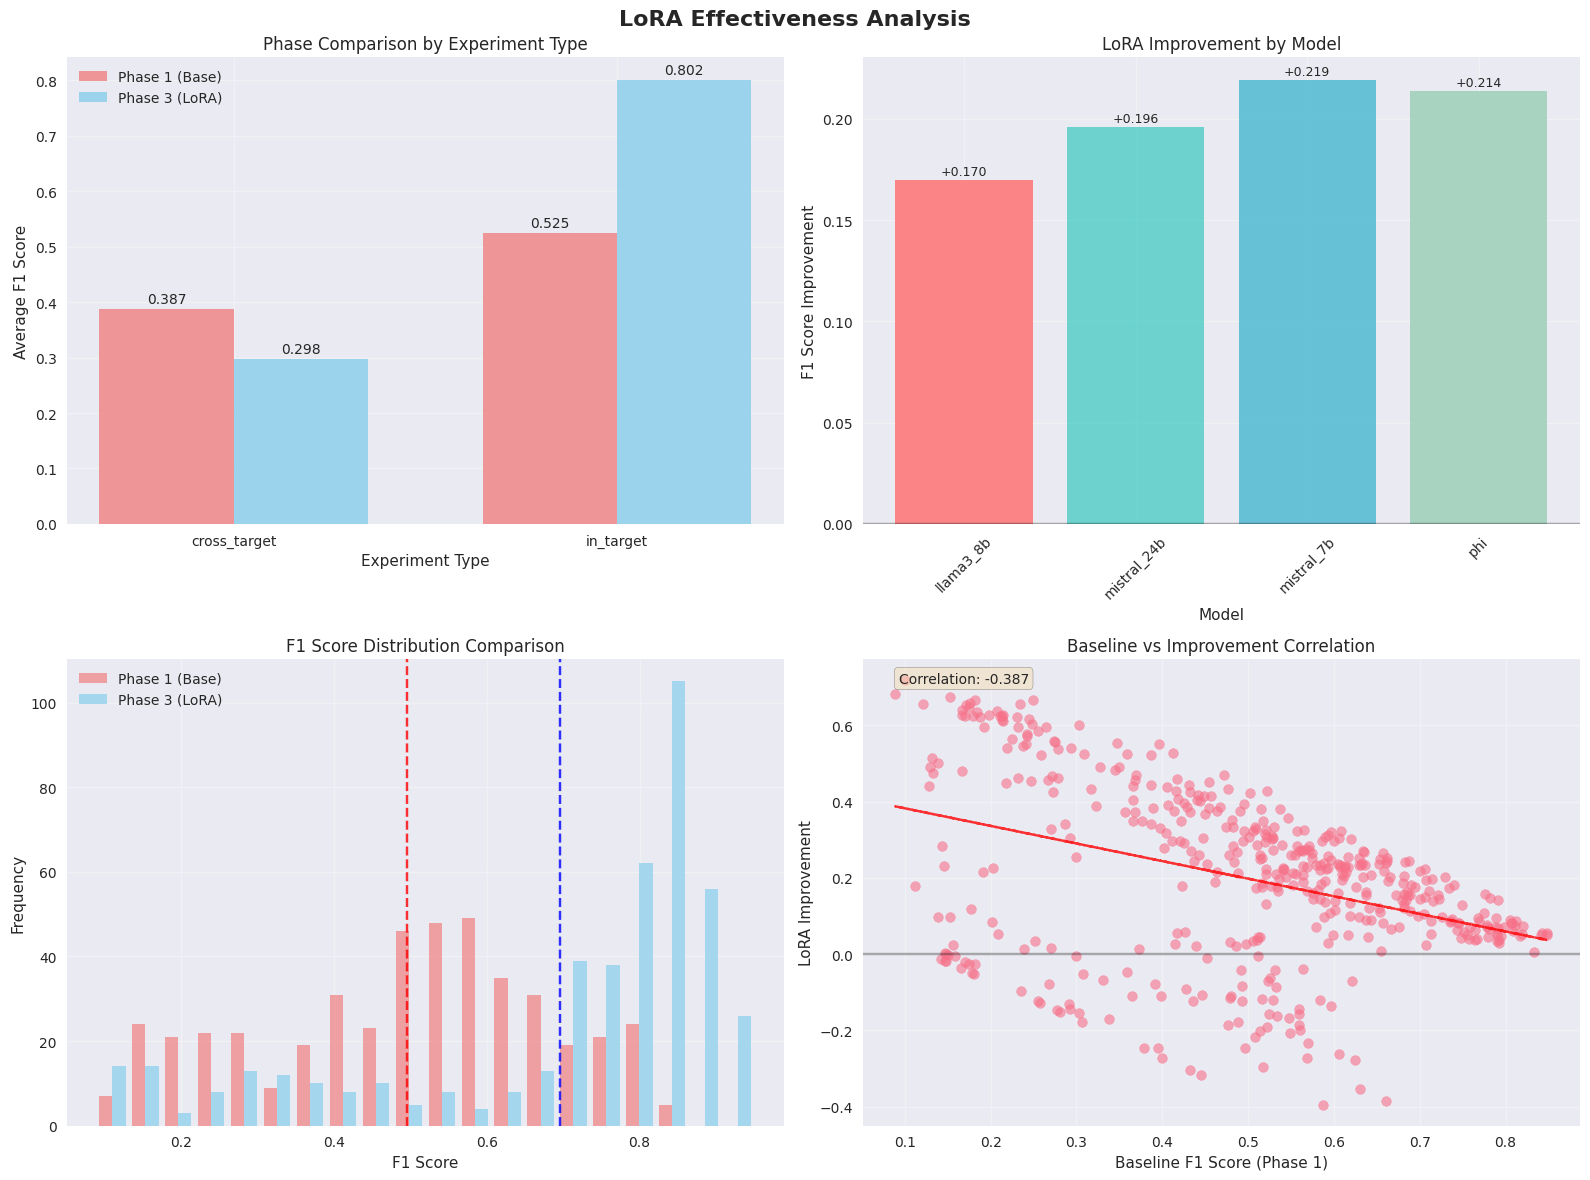

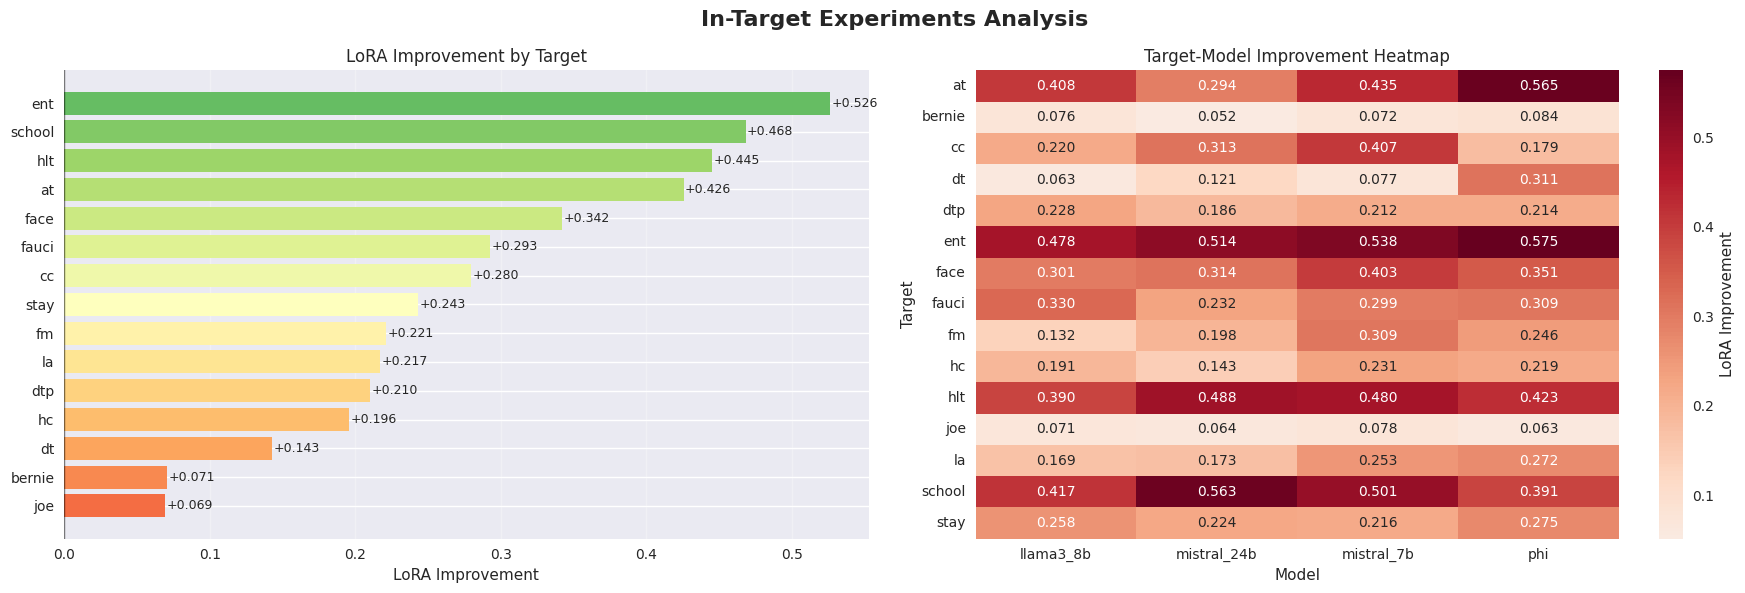

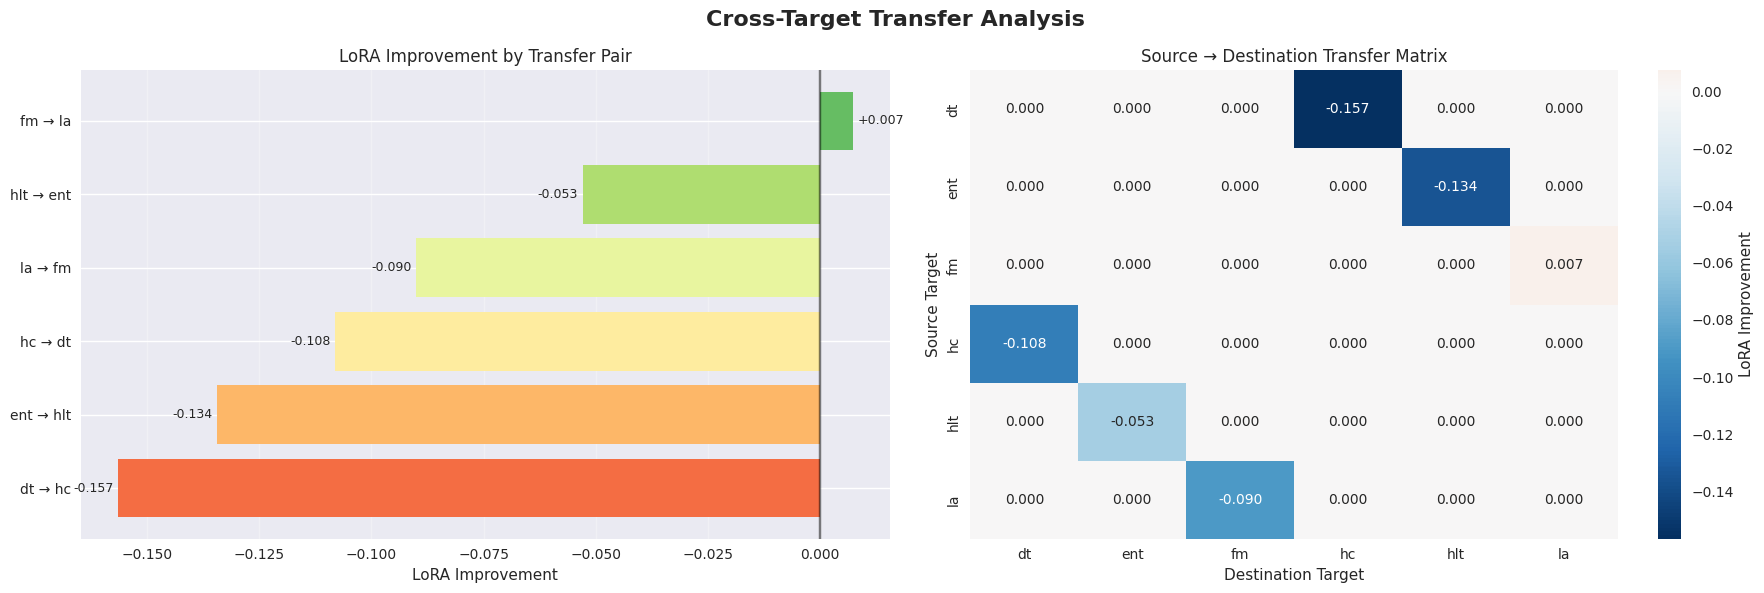

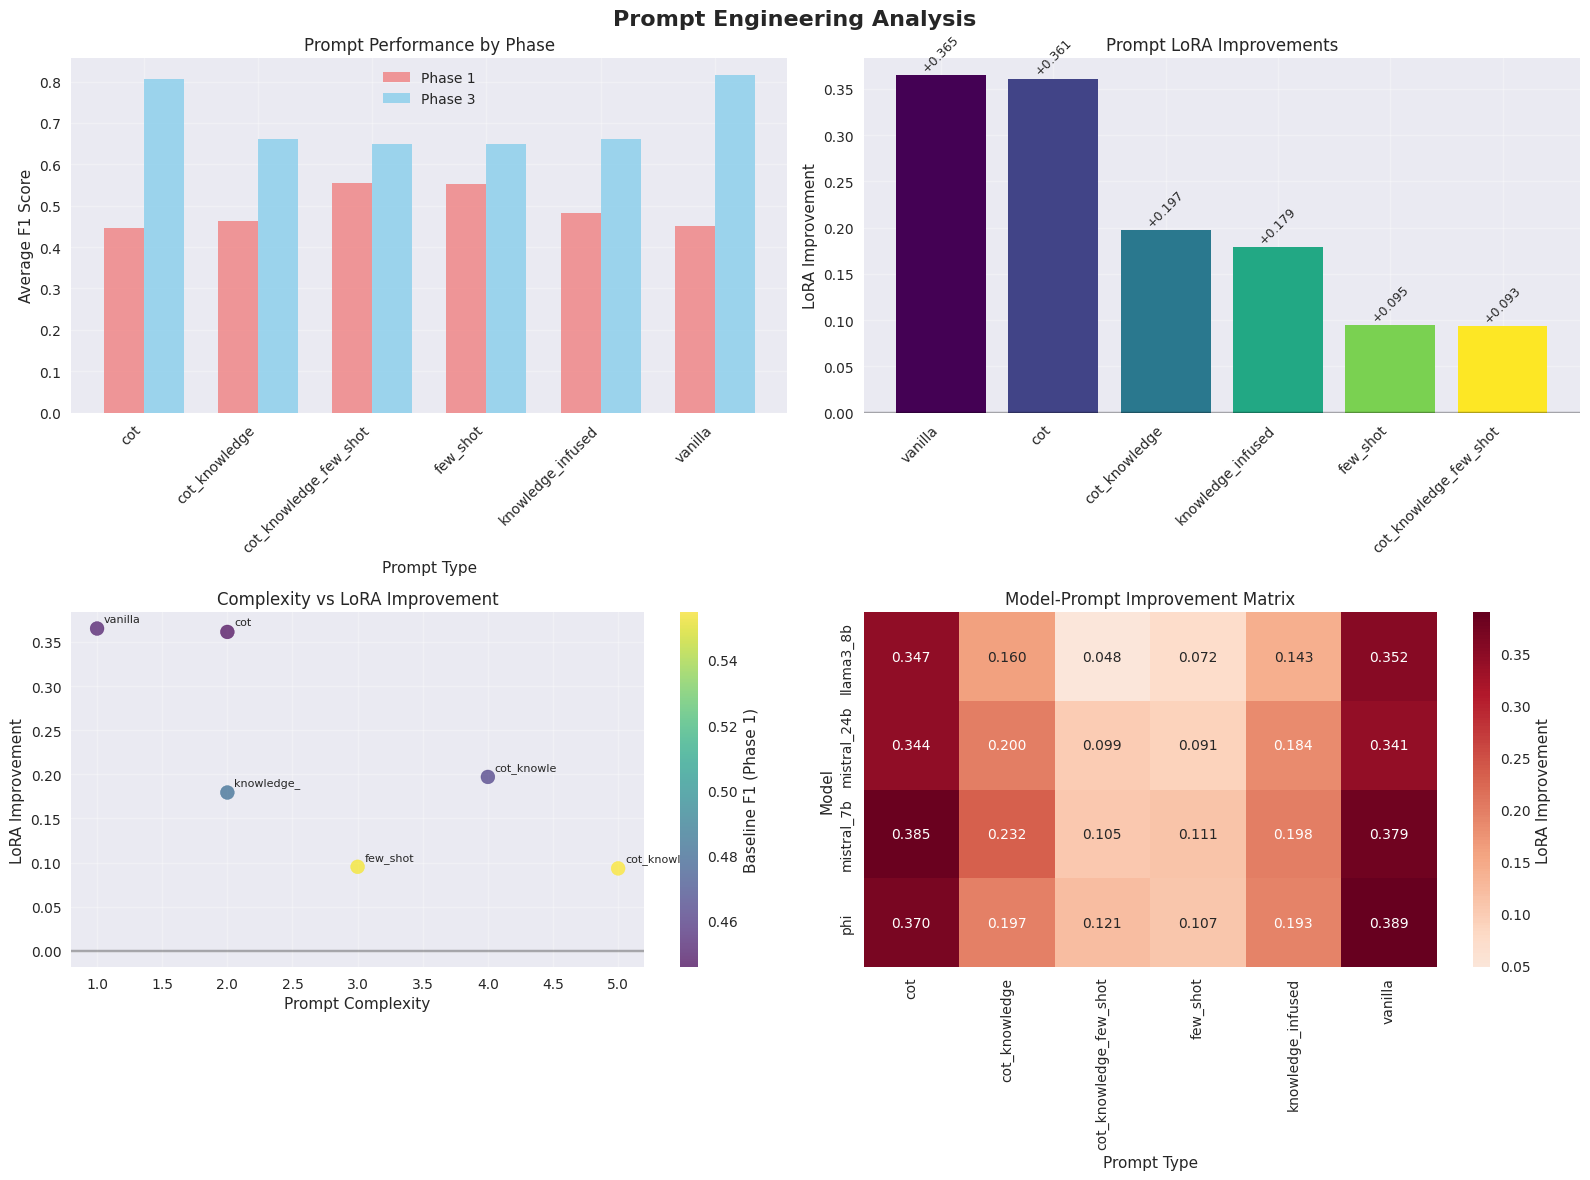

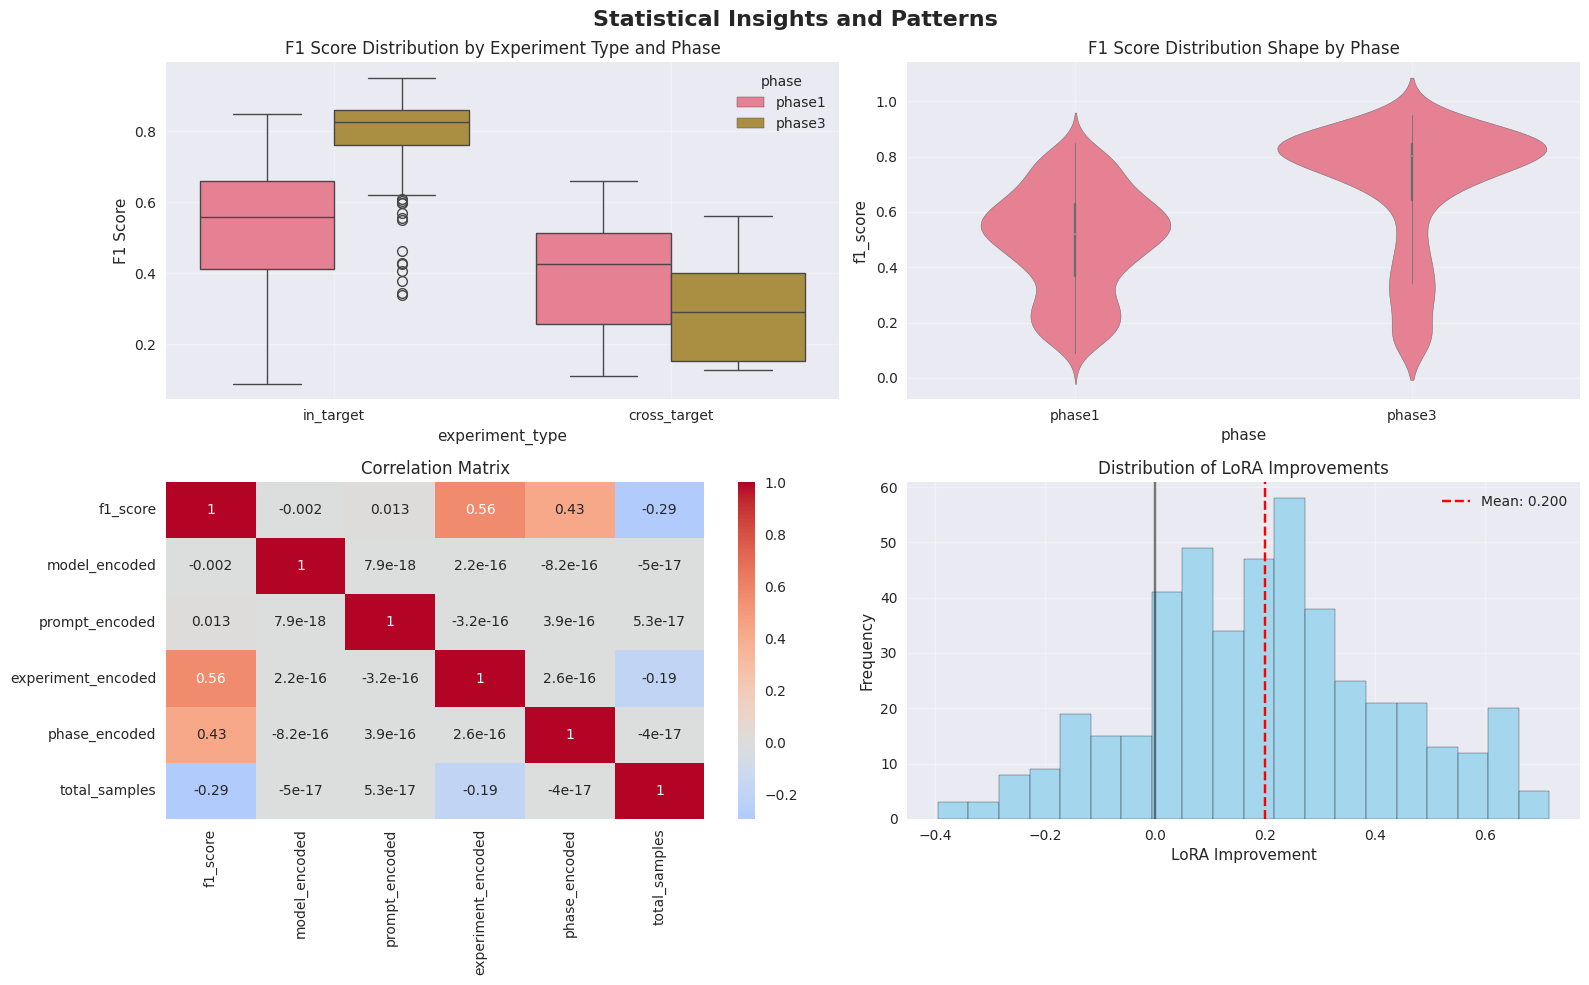

✨ All visualizations created successfully!

📊 Visualization Summary:
1. Overall LoRA effectiveness comparison
2. Target-specific and transfer-specific analysis
3. Prompt engineering insights
4. Statistical patterns and distributions


In [25]:
# ==========================================
# INTERESTING VISUALIZATIONS
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.patches import Rectangle
import warnings
warnings.filterwarnings('ignore')

# Set style for better looking plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("🎨 CREATING VISUALIZATIONS...")
print("="*50)

# ==========================================
# 1. OVERALL EFFECTIVENESS COMPARISON
# ==========================================

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('LoRA Effectiveness Analysis', fontsize=16, fontweight='bold')

# 1.1 Overall Phase Comparison by Experiment Type
experiment_phase_data = df.groupby(['experiment_type', 'phase'])['f1_score'].mean().unstack()

x = np.arange(len(experiment_phase_data.index))
width = 0.35

bars1 = ax1.bar(x - width/2, experiment_phase_data['phase1'], width, 
                label='Phase 1 (Base)', alpha=0.8, color='lightcoral')
bars2 = ax1.bar(x + width/2, experiment_phase_data['phase3'], width, 
                label='Phase 3 (LoRA)', alpha=0.8, color='skyblue')

# Add value labels on bars
for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.005,
             f'{height:.3f}', ha='center', va='bottom', fontsize=10)

for bar in bars2:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.005,
             f'{height:.3f}', ha='center', va='bottom', fontsize=10)

ax1.set_xlabel('Experiment Type')
ax1.set_ylabel('Average F1 Score')
ax1.set_title('Phase Comparison by Experiment Type')
ax1.set_xticks(x)
ax1.set_xticklabels(experiment_phase_data.index)
ax1.legend()
ax1.grid(True, alpha=0.3)

# 1.2 Model Performance Comparison
model_phase_data = df.groupby(['model', 'phase'])['f1_score'].mean().unstack()
model_improvements = model_phase_data['phase3'] - model_phase_data['phase1']

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']
bars = ax2.bar(model_improvements.index, model_improvements.values, 
               color=colors, alpha=0.8)

# Add value labels
for bar in bars:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.001,
             f'{height:+.3f}', ha='center', va='bottom', fontsize=9)

ax2.set_xlabel('Model')
ax2.set_ylabel('F1 Score Improvement')
ax2.set_title('LoRA Improvement by Model')
ax2.tick_params(axis='x', rotation=45)
ax2.grid(True, alpha=0.3)
ax2.axhline(y=0, color='black', linestyle='-', alpha=0.3)

# 1.3 Distribution Comparison
phase1_scores = df[df['phase'] == 'phase1']['f1_score']
phase3_scores = df[df['phase'] == 'phase3']['f1_score']

ax3.hist([phase1_scores, phase3_scores], bins=20, alpha=0.7, 
         label=['Phase 1 (Base)', 'Phase 3 (LoRA)'], color=['lightcoral', 'skyblue'])
ax3.set_xlabel('F1 Score')
ax3.set_ylabel('Frequency')
ax3.set_title('F1 Score Distribution Comparison')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Add mean lines
ax3.axvline(phase1_scores.mean(), color='red', linestyle='--', alpha=0.8, 
           label=f'Phase 1 Mean: {phase1_scores.mean():.3f}')
ax3.axvline(phase3_scores.mean(), color='blue', linestyle='--', alpha=0.8,
           label=f'Phase 3 Mean: {phase3_scores.mean():.3f}')

# 1.4 Improvement vs Baseline Correlation
baseline_vs_improvement = []
for _, row in df[df['phase'] == 'phase3'].iterrows():
    # Find matching baseline
    baseline_row = df[
        (df['phase'] == 'phase1') & 
        (df['model'] == row['model']) & 
        (df['prompt_type'] == row['prompt_type']) & 
        (df['experiment_type'] == row['experiment_type']) &
        (df['target'] == row['target']) &
        (df['source_target'] == row['source_target']) &
        (df['dest_target'] == row['dest_target'])
    ]
    
    if not baseline_row.empty:
        baseline_score = baseline_row['f1_score'].iloc[0]
        improvement = row['f1_score'] - baseline_score
        baseline_vs_improvement.append((baseline_score, improvement))

if baseline_vs_improvement:
    baselines, improvements = zip(*baseline_vs_improvement)
    ax4.scatter(baselines, improvements, alpha=0.6, s=50)
    ax4.set_xlabel('Baseline F1 Score (Phase 1)')
    ax4.set_ylabel('LoRA Improvement')
    ax4.set_title('Baseline vs Improvement Correlation')
    ax4.grid(True, alpha=0.3)
    ax4.axhline(y=0, color='black', linestyle='-', alpha=0.3)
    
    # Add trend line
    z = np.polyfit(baselines, improvements, 1)
    p = np.poly1d(z)
    ax4.plot(baselines, p(baselines), "r--", alpha=0.8)
    
    # Calculate correlation
    correlation = np.corrcoef(baselines, improvements)[0,1]
    ax4.text(0.05, 0.95, f'Correlation: {correlation:.3f}', 
             transform=ax4.transAxes, bbox=dict(boxstyle="round", facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

# ==========================================
# 2. TARGET-SPECIFIC ANALYSIS
# ==========================================

# Separate in-target and cross-target for detailed analysis
in_target_df = df[df['experiment_type'] == 'in_target'].copy()
cross_target_df = df[df['experiment_type'] == 'cross_target'].copy()

# 2.1 In-Target Analysis
if not in_target_df.empty:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))
    fig.suptitle('In-Target Experiments Analysis', fontsize=16, fontweight='bold')
    
    # Target improvements
    target_analysis = in_target_df.groupby(['target', 'phase'])['f1_score'].mean().unstack()
    target_improvements = target_analysis['phase3'] - target_analysis['phase1']
    target_improvements = target_improvements.dropna().sort_values(ascending=True)
    
    # Horizontal bar chart for better readability
    colors = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(target_improvements)))
    bars = ax1.barh(range(len(target_improvements)), target_improvements.values, color=colors)
    ax1.set_yticks(range(len(target_improvements)))
    ax1.set_yticklabels(target_improvements.index)
    ax1.set_xlabel('LoRA Improvement')
    ax1.set_title('LoRA Improvement by Target')
    ax1.grid(True, alpha=0.3, axis='x')
    ax1.axvline(x=0, color='black', linestyle='-', alpha=0.5)
    
    # Add value labels
    for i, bar in enumerate(bars):
        width = bar.get_width()
        ax1.text(width + 0.001 if width >= 0 else width - 0.001, bar.get_y() + bar.get_height()/2,
                f'{width:+.3f}', ha='left' if width >= 0 else 'right', va='center', fontsize=9)
    
    # Target performance heatmap by model
    target_model_data = in_target_df.groupby(['target', 'model', 'phase'])['f1_score'].mean().unstack()
    improvements_pivot = target_model_data['phase3'] - target_model_data['phase1']
    improvements_heatmap = improvements_pivot.unstack().fillna(0)
    
    if not improvements_heatmap.empty:
        sns.heatmap(improvements_heatmap, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
                   ax=ax2, cbar_kws={'label': 'LoRA Improvement'})
        ax2.set_title('Target-Model Improvement Heatmap')
        ax2.set_xlabel('Model')
        ax2.set_ylabel('Target')
    
    plt.tight_layout()
    plt.show()

# 2.2 Cross-Target Analysis  
if not cross_target_df.empty:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))
    fig.suptitle('Cross-Target Transfer Analysis', fontsize=16, fontweight='bold')
    
    # Transfer pair improvements
    cross_target_df['transfer_pair'] = cross_target_df['source_target'] + ' → ' + cross_target_df['dest_target']
    pair_analysis = cross_target_df.groupby(['transfer_pair', 'phase'])['f1_score'].mean().unstack()
    pair_improvements = pair_analysis['phase3'] - pair_analysis['phase1']
    pair_improvements = pair_improvements.dropna().sort_values(ascending=True)
    
    colors = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(pair_improvements)))
    bars = ax1.barh(range(len(pair_improvements)), pair_improvements.values, color=colors)
    ax1.set_yticks(range(len(pair_improvements)))
    ax1.set_yticklabels(pair_improvements.index)
    ax1.set_xlabel('LoRA Improvement')
    ax1.set_title('LoRA Improvement by Transfer Pair')
    ax1.grid(True, alpha=0.3, axis='x')
    ax1.axvline(x=0, color='black', linestyle='-', alpha=0.5)
    
    # Add value labels
    for i, bar in enumerate(bars):
        width = bar.get_width()
        ax1.text(width + 0.001 if width >= 0 else width - 0.001, bar.get_y() + bar.get_height()/2,
                f'{width:+.3f}', ha='left' if width >= 0 else 'right', va='center', fontsize=9)
    
    # Transfer matrix
    transfer_matrix = cross_target_df.groupby(['source_target', 'dest_target', 'phase'])['f1_score'].mean().unstack()
    transfer_improvements = transfer_matrix['phase3'] - transfer_matrix['phase1']
    transfer_pivot = transfer_improvements.unstack().fillna(0)
    
    if not transfer_pivot.empty:
        sns.heatmap(transfer_pivot, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
                   ax=ax2, cbar_kws={'label': 'LoRA Improvement'})
        ax2.set_title('Source → Destination Transfer Matrix')
        ax2.set_xlabel('Destination Target')
        ax2.set_ylabel('Source Target')
    
    plt.tight_layout()
    plt.show()

# ==========================================
# 3. PROMPT ANALYSIS VISUALIZATIONS
# ==========================================

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Prompt Engineering Analysis', fontsize=16, fontweight='bold')

# 3.1 Prompt Performance by Phase
prompt_phase_data = df.groupby(['prompt_type', 'phase'])['f1_score'].mean().unstack()

x = np.arange(len(prompt_phase_data.index))
width = 0.35

bars1 = ax1.bar(x - width/2, prompt_phase_data['phase1'], width, 
                label='Phase 1', alpha=0.8, color='lightcoral')
bars2 = ax1.bar(x + width/2, prompt_phase_data['phase3'], width, 
                label='Phase 3', alpha=0.8, color='skyblue')

ax1.set_xlabel('Prompt Type')
ax1.set_ylabel('Average F1 Score')
ax1.set_title('Prompt Performance by Phase')
ax1.set_xticks(x)
ax1.set_xticklabels(prompt_phase_data.index, rotation=45, ha='right')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 3.2 Prompt Improvements
prompt_improvements = prompt_phase_data['phase3'] - prompt_phase_data['phase1']
prompt_improvements = prompt_improvements.dropna().sort_values(ascending=False)

colors = plt.cm.viridis(np.linspace(0, 1, len(prompt_improvements)))
bars = ax2.bar(range(len(prompt_improvements)), prompt_improvements.values, color=colors)
ax2.set_xticks(range(len(prompt_improvements)))
ax2.set_xticklabels(prompt_improvements.index, rotation=45, ha='right')
ax2.set_ylabel('LoRA Improvement')
ax2.set_title('Prompt LoRA Improvements')
ax2.grid(True, alpha=0.3)
ax2.axhline(y=0, color='black', linestyle='-', alpha=0.3)

# Add value labels
for i, bar in enumerate(bars):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.001 if height >= 0 else height - 0.002,
             f'{height:+.3f}', ha='center', va='bottom' if height >= 0 else 'top', 
             fontsize=9, rotation=45)

# 3.3 Prompt Complexity vs Performance
prompt_hierarchy = {
    'vanilla': 1, 'knowledge_infused': 2, 'few_shot': 3,
    'cot': 2, 'cot_knowledge': 4, 'cot_knowledge_few_shot': 5
}

complexity_data = []
for prompt in df['prompt_type'].unique():
    if prompt in prompt_hierarchy:
        complexity = prompt_hierarchy[prompt]
        phase1_score = df[(df['prompt_type'] == prompt) & (df['phase'] == 'phase1')]['f1_score'].mean()
        phase3_score = df[(df['prompt_type'] == prompt) & (df['phase'] == 'phase3')]['f1_score'].mean()
        if not pd.isna(phase1_score) and not pd.isna(phase3_score):
            improvement = phase3_score - phase1_score
            complexity_data.append((complexity, phase1_score, phase3_score, improvement, prompt))

if complexity_data:
    complexities, phase1_scores, phase3_scores, improvements, prompt_names = zip(*complexity_data)
    
    # Scatter plot with different colors for each prompt
    scatter = ax3.scatter(complexities, improvements, c=phase1_scores, s=100, 
                         alpha=0.7, cmap='viridis')
    
    # Add labels for each point
    for i, prompt in enumerate(prompt_names):
        ax3.annotate(prompt[:10], (complexities[i], improvements[i]), 
                    xytext=(5, 5), textcoords='offset points', fontsize=8)
    
    ax3.set_xlabel('Prompt Complexity')
    ax3.set_ylabel('LoRA Improvement')
    ax3.set_title('Complexity vs LoRA Improvement')
    ax3.grid(True, alpha=0.3)
    ax3.axhline(y=0, color='black', linestyle='-', alpha=0.3)
    
    # Add colorbar
    cbar = plt.colorbar(scatter, ax=ax3)
    cbar.set_label('Baseline F1 (Phase 1)')

# 3.4 Model-Prompt Interaction Heatmap
model_prompt_data = df.groupby(['model', 'prompt_type', 'phase'])['f1_score'].mean().unstack()
model_prompt_improvements = model_prompt_data['phase3'] - model_prompt_data['phase1']
model_prompt_pivot = model_prompt_improvements.unstack().fillna(0)

if not model_prompt_pivot.empty:
    sns.heatmap(model_prompt_pivot, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
               ax=ax4, cbar_kws={'label': 'LoRA Improvement'})
    ax4.set_title('Model-Prompt Improvement Matrix')
    ax4.set_xlabel('Prompt Type')
    ax4.set_ylabel('Model')

plt.tight_layout()
plt.show()

# ==========================================
# 4. STATISTICAL INSIGHTS VISUALIZATION
# ==========================================

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Statistical Insights and Patterns', fontsize=16, fontweight='bold')

# 4.1 Box plot comparison by experiment type and phase
df_melted = df.melt(id_vars=['experiment_type', 'phase'], value_vars=['f1_score'], 
                    var_name='metric', value_name='score')

sns.boxplot(data=df_melted, x='experiment_type', y='score', hue='phase', ax=ax1)
ax1.set_title('F1 Score Distribution by Experiment Type and Phase')
ax1.set_ylabel('F1 Score')
ax1.grid(True, alpha=0.3)

# 4.2 Violin plot for detailed distribution
sns.violinplot(data=df, x='phase', y='f1_score', ax=ax2)
ax2.set_title('F1 Score Distribution Shape by Phase')
ax2.grid(True, alpha=0.3)

# 4.3 Correlation matrix of different factors
# Create numerical encoding for categorical variables
df_corr = df.copy()
df_corr['model_encoded'] = pd.Categorical(df_corr['model']).codes
df_corr['prompt_encoded'] = pd.Categorical(df_corr['prompt_type']).codes
df_corr['experiment_encoded'] = pd.Categorical(df_corr['experiment_type']).codes
df_corr['phase_encoded'] = pd.Categorical(df_corr['phase']).codes

correlation_matrix = df_corr[['f1_score', 'model_encoded', 'prompt_encoded', 
                             'experiment_encoded', 'phase_encoded', 'total_samples']].corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, ax=ax3)
ax3.set_title('Correlation Matrix')

# 4.4 Performance improvement distribution
all_improvements = []
for _, row in df[df['phase'] == 'phase3'].iterrows():
    baseline_row = df[
        (df['phase'] == 'phase1') & 
        (df['model'] == row['model']) & 
        (df['prompt_type'] == row['prompt_type']) & 
        (df['experiment_type'] == row['experiment_type']) &
        (df['target'] == row['target']) &
        (df['source_target'] == row['source_target']) &
        (df['dest_target'] == row['dest_target'])
    ]
    
    if not baseline_row.empty:
        improvement = row['f1_score'] - baseline_row['f1_score'].iloc[0]
        all_improvements.append(improvement)

if all_improvements:
    ax4.hist(all_improvements, bins=20, alpha=0.7, color='skyblue', edgecolor='black')
    ax4.axvline(np.mean(all_improvements), color='red', linestyle='--', 
               label=f'Mean: {np.mean(all_improvements):.3f}')
    ax4.axvline(0, color='black', linestyle='-', alpha=0.5)
    ax4.set_xlabel('LoRA Improvement')
    ax4.set_ylabel('Frequency')
    ax4.set_title('Distribution of LoRA Improvements')
    ax4.legend()
    ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✨ All visualizations created successfully!")
print("\n📊 Visualization Summary:")
print("1. Overall LoRA effectiveness comparison")
print("2. Target-specific and transfer-specific analysis")
print("3. Prompt engineering insights")
print("4. Statistical patterns and distributions")